In [ ]:
#Adding the files from the file explorer
from google.colab import files
uploaded = files.upload()


Saving Responses CSV FIle.csv to Responses CSV FIle.csv


In [ ]:
import pandas as pd
#Displaying the first 5 rows of the CSV File
df = pd.read_csv("Responses CSV FIle.csv")
df.head()


,Age,Course,Year of Study\n,Average Academic Performance (CGPA or Percentage),Attendance Rate,Interest in the Course,How often do you seek help from faculty or peers when stuck in a course?,How confident are you in understanding engineering subjects this semester?,Study Hours per Day,Type of Learning Preference,...,How often do you feel overwhelmed by academic workload?,Do you engage in extracurricular or sports activities?,Quality of Teaching and Learning Resources,"Availability of Academic Support (e.g., mentoring, tutoring)",Satisfaction with College Administration Support,Frequency of Counseling or Mentorship Sessions,Would you consider dropping out of your course?,"In your opinion, what are the main reasons students drop out?",What can institutions do to reduce dropout rates?,What motivates you the most to continue your studies?
0,18–20,IS,2nd Year,70–80%,80–89%,5,NaN,NaN,More than 6 hours,Reading/Writing,...,Always,Never,5,5,5,Never,Already dropped once and rejoined,NaN,H,H
1,18–20,Information science,2nd Year,Above 80%,80–89%,4,Rarely,3.0,Less than 1 hour,Reading/Writing,...,Often,Rarely,4,3,3,Monthly,No,NaN,NaN,NaN
2,18–20,ISE,2nd Year,Above 80%,90% and above,5,Always,5.0,2–4 hours,Reading/Writing,...,Sometimes,Regularly,3,4,2,Rarely,No,The Reasons why most students dropout are:\n1)...,1)They can put up seminars that might allow se...,"1) I really like the subject if ISE, it is ver..."
3,Below 18,ISE,1st Year,Above 80%,90% and above,5,Rarely,4.0,2–4 hours,Reading/Writing,...,Sometimes,Occasionally,5,4,4,Rarely,No,Financial problems and disinterest,Provide payments plans and make kectures inter...,Money
4,Above 26,B E,4th Year,Above 80%,80–89%,5,Sometimes,4.0,2–4 hours,Reading/Writing,...,Never,Occasionally,3,3,4,Once a semester,No,Stress,Mentoring from seniors and lecturers,Ambition


In [3]:
!pip install category_encoders --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re #This is the Re Module for the conversion for Eng to Sequences
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/content/Responses CSV FIle.csv"

df = pd.read_csv(DATA_PATH)
print("Loaded successfully. Shape:", df.shape)
df.head()


Loaded successfully. Shape: (40, 30)


,Age,Course,Year of Study\n,Average Academic Performance (CGPA or Percentage),Attendance Rate,Interest in the Course,How often do you seek help from faculty or peers when stuck in a course?,How confident are you in understanding engineering subjects this semester?,Study Hours per Day,Type of Learning Preference,...,How often do you feel overwhelmed by academic workload?,Do you engage in extracurricular or sports activities?,Quality of Teaching and Learning Resources,"Availability of Academic Support (e.g., mentoring, tutoring)",Satisfaction with College Administration Support,Frequency of Counseling or Mentorship Sessions,Would you consider dropping out of your course?,"In your opinion, what are the main reasons students drop out?",What can institutions do to reduce dropout rates?,What motivates you the most to continue your studies?
0,18–20,IS,2nd Year,70–80%,80–89%,5,NaN,NaN,More than 6 hours,Reading/Writing,...,Always,Never,5,5,5,Never,Already dropped once and rejoined,NaN,H,H
1,18–20,Information science,2nd Year,Above 80%,80–89%,4,Rarely,3.0,Less than 1 hour,Reading/Writing,...,Often,Rarely,4,3,3,Monthly,No,NaN,NaN,NaN
2,18–20,ISE,2nd Year,Above 80%,90% and above,5,Always,5.0,2–4 hours,Reading/Writing,...,Sometimes,Regularly,3,4,2,Rarely,No,The Reasons why most students dropout are:\n1)...,1)They can put up seminars that might allow se...,"1) I really like the subject if ISE, it is ver..."
3,Below 18,ISE,1st Year,Above 80%,90% and above,5,Rarely,4.0,2–4 hours,Reading/Writing,...,Sometimes,Occasionally,5,4,4,Rarely,No,Financial problems and disinterest,Provide payments plans and make kectures inter...,Money
4,Above 26,B E,4th Year,Above 80%,80–89%,5,Sometimes,4.0,2–4 hours,Reading/Writing,...,Never,Occasionally,3,3,4,Once a semester,No,Stress,Mentoring from seniors and lecturers,Ambition


In [ ]:
#Understanding the type of data that the fields have taken during the SUrvey

print("=== BASIC INFO ===")
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isna().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Unique values check
#FInding out if there are any duplicate rows or not
print("\n=== UNIQUE COUNTS PER COLUMN ===")
display(df.nunique())


=== BASIC INFO ===


,Age,Course,Year of Study\n,Average Academic Performance (CGPA or Percentage),Attendance Rate,Interest in the Course,How often do you seek help from faculty or peers when stuck in a course?,How confident are you in understanding engineering subjects this semester?,Study Hours per Day,Type of Learning Preference,...,How often do you feel overwhelmed by academic workload?,Do you engage in extracurricular or sports activities?,Quality of Teaching and Learning Resources,"Availability of Academic Support (e.g., mentoring, tutoring)",Satisfaction with College Administration Support,Frequency of Counseling or Mentorship Sessions,Would you consider dropping out of your course?,"In your opinion, what are the main reasons students drop out?",What can institutions do to reduce dropout rates?,What motivates you the most to continue your studies?
0,18–20,IS,2nd Year,70–80%,80–89%,5,NaN,NaN,More than 6 hours,Reading/Writing,...,Always,Never,5,5,5,Never,Already dropped once and rejoined,NaN,H,H
1,18–20,Information science,2nd Year,Above 80%,80–89%,4,Rarely,3.0,Less than 1 hour,Reading/Writing,...,Often,Rarely,4,3,3,Monthly,No,NaN,NaN,NaN
2,18–20,ISE,2nd Year,Above 80%,90% and above,5,Always,5.0,2–4 hours,Reading/Writing,...,Sometimes,Regularly,3,4,2,Rarely,No,The Reasons why most students dropout are:\n1)...,1)They can put up seminars that might allow se...,"1) I really like the subject if ISE, it is ver..."
3,Below 18,ISE,1st Year,Above 80%,90% and above,5,Rarely,4.0,2–4 hours,Reading/Writing,...,Sometimes,Occasionally,5,4,4,Rarely,No,Financial problems and disinterest,Provide payments plans and make kectures inter...,Money
4,Above 26,B E,4th Year,Above 80%,80–89%,5,Sometimes,4.0,2–4 hours,Reading/Writing,...,Never,Occasionally,3,3,4,Once a semester,No,Stress,Mentoring from seniors and lecturers,Ambition



Data Types:
  Age                                                                          object
  Course                                                                       object
Year of Study\n                                                                object
Average Academic Performance (CGPA or Percentage)                              object
Attendance Rate                                                                object
  Interest in the Course                                                        int64
How often do you seek help from faculty or peers when stuck in a course?       object
How confident are you in understanding engineering subjects this semester?    float64
Study Hours per Day                                                            object
Type of Learning Preference                                                    object
Do you depend on scholarships or loans?                                        object
  Do financial problems affect your studi

,0
Age,4
Course,33
Year of Study\n,4
Average Academic Performance (CGPA or Percentage),3
Attendance Rate,6
Interest in the Course,4
How often do you seek help from faculty or peers when stuck in a course?,5
How confident are you in understanding engineering subjects this semester?,5
Study Hours per Day,4
Type of Learning Preference,4


In [ ]:
#Data Cleaning Process
# Removing the White Spaces, Underscores and any punctuation marks

def clean_column_names(df):
    new_cols = []
    for c in df.columns:
        c2 = c.strip()
        c2 = re.sub(r"[ \t]+", "_", c2)
        c2 = re.sub(r"[^\w_]", "", c2)
        new_cols.append(c2)
    df.columns = new_cols
    return df

df = clean_column_names(df)
df.head()


,Age,Course,Year_of_Study,Average_Academic_Performance_CGPA_or_Percentage,Attendance_Rate,Interest_in_the_Course,How_often_do_you_seek_help_from_faculty_or_peers_when_stuck_in_a_course,How_confident_are_you_in_understanding_engineering_subjects_this_semester,Study_Hours_per_Day,Type_of_Learning_Preference,...,How_often_do_you_feel_overwhelmed_by_academic_workload,Do_you_engage_in_extracurricular_or_sports_activities,Quality_of_Teaching_and_Learning_Resources,Availability_of_Academic_Support_eg_mentoring_tutoring,Satisfaction_with_College_Administration_Support,Frequency_of_Counseling_or_Mentorship_Sessions,Would_you_consider_dropping_out_of_your_course,In_your_opinion_what_are_the_main_reasons_students_drop_out,What_can_institutions_do_to_reduce_dropout_rates,What_motivates_you_the_most_to_continue_your_studies
0,18–20,IS,2nd Year,70–80%,80–89%,5,NaN,NaN,More than 6 hours,Reading/Writing,...,Always,Never,5,5,5,Never,Already dropped once and rejoined,NaN,H,H
1,18–20,Information science,2nd Year,Above 80%,80–89%,4,Rarely,3.0,Less than 1 hour,Reading/Writing,...,Often,Rarely,4,3,3,Monthly,No,NaN,NaN,NaN
2,18–20,ISE,2nd Year,Above 80%,90% and above,5,Always,5.0,2–4 hours,Reading/Writing,...,Sometimes,Regularly,3,4,2,Rarely,No,The Reasons why most students dropout are:\n1)...,1)They can put up seminars that might allow se...,"1) I really like the subject if ISE, it is ver..."
3,Below 18,ISE,1st Year,Above 80%,90% and above,5,Rarely,4.0,2–4 hours,Reading/Writing,...,Sometimes,Occasionally,5,4,4,Rarely,No,Financial problems and disinterest,Provide payments plans and make kectures inter...,Money
4,Above 26,B E,4th Year,Above 80%,80–89%,5,Sometimes,4.0,2–4 hours,Reading/Writing,...,Never,Occasionally,3,3,4,Once a semester,No,Stress,Mentoring from seniors and lecturers,Ambition


In [ ]:
#Removing the all of the Unbalanced values like None, NaN, null, nan etc

def trim_strings(df):
    obj_cols = df.select_dtypes(include='object').columns
    for c in obj_cols:
        df[c] = df[c].astype(str).str.strip()
        df[c] = df[c].replace(["nan", "None", "NULL"], np.nan)
    return df

df = trim_strings(df)
df.head()


,Age,Course,Year_of_Study,Average_Academic_Performance_CGPA_or_Percentage,Attendance_Rate,Interest_in_the_Course,How_often_do_you_seek_help_from_faculty_or_peers_when_stuck_in_a_course,How_confident_are_you_in_understanding_engineering_subjects_this_semester,Study_Hours_per_Day,Type_of_Learning_Preference,...,How_often_do_you_feel_overwhelmed_by_academic_workload,Do_you_engage_in_extracurricular_or_sports_activities,Quality_of_Teaching_and_Learning_Resources,Availability_of_Academic_Support_eg_mentoring_tutoring,Satisfaction_with_College_Administration_Support,Frequency_of_Counseling_or_Mentorship_Sessions,Would_you_consider_dropping_out_of_your_course,In_your_opinion_what_are_the_main_reasons_students_drop_out,What_can_institutions_do_to_reduce_dropout_rates,What_motivates_you_the_most_to_continue_your_studies
0,18–20,IS,2nd Year,70–80%,80–89%,5,NaN,NaN,More than 6 hours,Reading/Writing,...,Always,Never,5,5,5,Never,Already dropped once and rejoined,NaN,H,H
1,18–20,Information science,2nd Year,Above 80%,80–89%,4,Rarely,3.0,Less than 1 hour,Reading/Writing,...,Often,Rarely,4,3,3,Monthly,No,NaN,NaN,NaN
2,18–20,ISE,2nd Year,Above 80%,90% and above,5,Always,5.0,2–4 hours,Reading/Writing,...,Sometimes,Regularly,3,4,2,Rarely,No,The Reasons why most students dropout are:\n1)...,1)They can put up seminars that might allow se...,"1) I really like the subject if ISE, it is ver..."
3,Below 18,ISE,1st Year,Above 80%,90% and above,5,Rarely,4.0,2–4 hours,Reading/Writing,...,Sometimes,Occasionally,5,4,4,Rarely,No,Financial problems and disinterest,Provide payments plans and make kectures inter...,Money
4,Above 26,B E,4th Year,Above 80%,80–89%,5,Sometimes,4.0,2–4 hours,Reading/Writing,...,Never,Occasionally,3,3,4,Once a semester,No,Stress,Mentoring from seniors and lecturers,Ambition


In [ ]:
#Conversion of all the Time Stamp to the date-time format 
#But those were removed from the CSV File itself before include in the data Processing 

def detect_dates(df):
    date_cols = []
    for c in df.columns:
        if df[c].dtype == 'object':
            sample = df[c].dropna().astype(str).head(20)
            joined = " ".join(sample)
            if re.search(r"\d{1,2}[-/]\d{1,2}[-/]\d{2,4}", joined) or re.search(r"\d{4}-\d{2}-\d{2}", joined):
                date_cols.append(c)
    return date_cols

date_cols = detect_dates(df)
print("Detected date columns:", date_cols)

for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df[date_cols].head()


Detected date columns: []


""
0
1
2
3
4


In [9]:
def coerce_numeric(df):
    converted = []
    for c in df.columns:
        if df[c].dtype == 'object':
            sample = df[c].dropna().astype(str)
            def isnum(x):
                x = x.replace(",", "").replace("%", "")
                return bool(re.fullmatch(r"[-+]?\d*\.?\d+", x))
            if len(sample) > 0 and np.mean([isnum(s) for s in sample]) > 0.6:
                df[c] = sample.str.replace(",", "").str.replace("%", "")
                df[c] = pd.to_numeric(df[c], errors='coerce')
                converted.append(c)
    return df, converted

df, converted_cols = coerce_numeric(df)
print("Converted to numeric:", converted_cols)


Converted to numeric: []


In [ ]:
# Drop duplicates
#Any column that has more than 80% missing, we are going to drop those columns
df = df.drop_duplicates()

missing_frac = df.isna().mean()
cols_to_drop = missing_frac[missing_frac > 0.8].index

print("Columns dropped (>80% missing):", list(cols_to_drop))

df = df.drop(columns=cols_to_drop)
df.shape


Columns dropped (>80% missing): []


(40, 30)

In [ ]:
#Categorise the columns into the Numeric type, Categorical or DateTime format
# NUmerical values are all those that have selecting values during the survey
#Categorical are the ones that have text input from the survey
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
date_cols = df.select_dtypes(include=['datetime']).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols[:10])
print("Datetime:", date_cols)


Numeric: ['Interest_in_the_Course', 'How_confident_are_you_in_understanding_engineering_subjects_this_semester', 'Do_financial_problems_affect_your_studies', 'Family_Support_for_Education', 'Level_of_Stress_or_Anxiety_Related_to_Studies', 'Do_you_feel_socially_isolated_or_left_out_in_college', 'Motivation_to_Continue_Studies', 'Quality_of_Teaching_and_Learning_Resources', 'Availability_of_Academic_Support_eg_mentoring_tutoring', 'Satisfaction_with_College_Administration_Support']
Categorical: ['Age', 'Course', 'Year_of_Study', 'Average_Academic_Performance_CGPA_or_Percentage', 'Attendance_Rate', 'How_often_do_you_seek_help_from_faculty_or_peers_when_stuck_in_a_course', 'Study_Hours_per_Day', 'Type_of_Learning_Preference', 'Do_you_depend_on_scholarships_or_loans', 'Parental_Education_Level']
Datetime: []


In [12]:
# No target column since this is unsupervised.
X = df.copy()
print("Data prepared for clustering. Shape:", X.shape)


Data prepared for clustering. Shape: (40, 30)


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])


In [14]:
X_processed = preprocess.fit_transform(X)
print("Processed data shape:", X_processed.shape)


Processed data shape: (40, 172)


In [15]:
from sklearn.cluster import KMeans

k = 3  # choose 3 clusters (you can try 2,3,4,5 later)
kmeans = KMeans(n_clusters=k, random_state=42)

clusters = kmeans.fit_predict(X_processed)
df['Cluster'] = clusters

print("Clustering done. Added 'Cluster' column.")
df[['Cluster']].head()


Clustering done. Added 'Cluster' column.


,Cluster
0,2
1,2
2,2
3,2
4,1


In [16]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary


,Interest_in_the_Course,How_confident_are_you_in_understanding_engineering_subjects_this_semester,Do_financial_problems_affect_your_studies,Family_Support_for_Education,Level_of_Stress_or_Anxiety_Related_to_Studies,Do_you_feel_socially_isolated_or_left_out_in_college,Motivation_to_Continue_Studies,Quality_of_Teaching_and_Learning_Resources,Availability_of_Academic_Support_eg_mentoring_tutoring,Satisfaction_with_College_Administration_Support
Cluster,,,,,,,,,,
0,3.461538,3.000000,1.769231,4.833333,3.000000,2.230769,2.923077,3.000000,3.000000,2.615385
1,3.500000,3.333333,3.166667,3.666667,4.333333,3.500000,3.166667,2.166667,1.833333,2.833333
2,4.476190,3.500000,1.285714,4.904762,2.714286,1.809524,4.190476,3.952381,3.809524,3.333333


In [17]:
cat_summary = df.groupby("Cluster")[cat_cols].agg(lambda x: x.value_counts().index[0])
cat_summary


,Age,Course,Year_of_Study,Average_Academic_Performance_CGPA_or_Percentage,Attendance_Rate,How_often_do_you_seek_help_from_faculty_or_peers_when_stuck_in_a_course,Study_Hours_per_Day,Type_of_Learning_Preference,Do_you_depend_on_scholarships_or_loans,Parental_Education_Level,Number_of_Dependents_in_Family,Do_you_have_a_parttime_job_or_other_major_commitments,Do_you_have_any_health_issues_affecting_your_studies,How_often_do_you_feel_overwhelmed_by_academic_workload,Do_you_engage_in_extracurricular_or_sports_activities,Frequency_of_Counseling_or_Mentorship_Sessions,Would_you_consider_dropping_out_of_your_course,In_your_opinion_what_are_the_main_reasons_students_drop_out,What_can_institutions_do_to_reduce_dropout_rates,What_motivates_you_the_most_to_continue_your_studies
Cluster,,,,,,,,,,,,,,,,,,,,
0,18–20,Computer Science Engineering,2nd Year,Above 80%,80–89%,Sometimes,1–2 hours,"Visual (videos, diagrams)",Loan,College graduate,3–4,No,No,Sometimes,Regularly,Rarely,No,Backlogs,Make learning more interactive,Getting a good job ig :(
1,Above 26,B E,2nd Year,Above 80%,80–89%,Sometimes,2–4 hours,"Visual (videos, diagrams)",Scholarship,Postgraduate or higher,2,No,"Yes, mental health issues",Sometimes,Occasionally,Rarely,No,Stress,Mentoring from seniors and lecturers,Ambition
2,18–20,ISE,2nd Year,Above 80%,80–89%,Often,Less than 1 hour,Reading/Writing,Scholarship,"Professional degree (e.g., Doctor, Engineer, e...",2,No,No,Sometimes,Occasionally,Monthly,No,The Reasons why most students dropout are:\n1)...,H,Money


In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce X_processed to 2 dimensions for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)


In [24]:
risk_map = {
    0: "High Risk",
    1: "Medium Risk",
    2: "Low Risk"
}

df['RiskLevel'] = df['Cluster'].map(risk_map)
df[['Cluster', 'RiskLevel']].head()


,Cluster,RiskLevel
0,2,Low Risk
1,2,Low Risk
2,2,Low Risk
3,2,Low Risk
4,1,Medium Risk


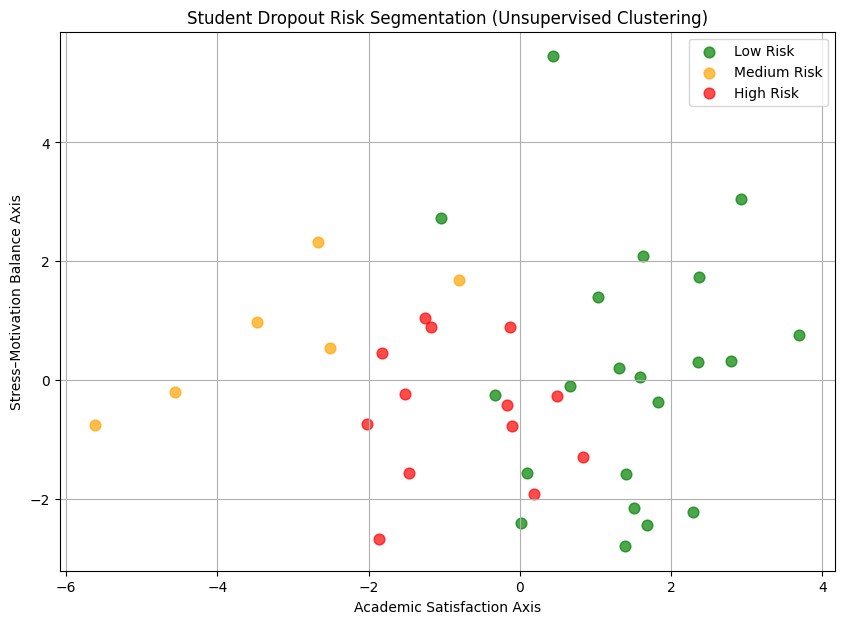

In [25]:
plt.figure(figsize=(10, 7))
colors = {'Low Risk':'green', 'Medium Risk':'orange', 'High Risk':'red'}

for risk in df['RiskLevel'].unique():
    idx = df['RiskLevel'] == risk
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                label=risk, alpha=0.7, s=60,
                color=colors[risk])

plt.xlabel("Academic Satisfaction Axis")
plt.ylabel("Stress–Motivation Balance Axis")
plt.title("Student Dropout Risk Segmentation (Unsupervised Clustering)")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary


,Interest_in_the_Course,How_confident_are_you_in_understanding_engineering_subjects_this_semester,Do_financial_problems_affect_your_studies,Family_Support_for_Education,Level_of_Stress_or_Anxiety_Related_to_Studies,Do_you_feel_socially_isolated_or_left_out_in_college,Motivation_to_Continue_Studies,Quality_of_Teaching_and_Learning_Resources,Availability_of_Academic_Support_eg_mentoring_tutoring,Satisfaction_with_College_Administration_Support
Cluster,,,,,,,,,,
0,3.461538,3.000000,1.769231,4.833333,3.000000,2.230769,2.923077,3.000000,3.000000,2.615385
1,3.500000,3.333333,3.166667,3.666667,4.333333,3.500000,3.166667,2.166667,1.833333,2.833333
2,4.476190,3.500000,1.285714,4.904762,2.714286,1.809524,4.190476,3.952381,3.809524,3.333333


In [23]:
cat_summary = df.groupby("Cluster")[cat_cols].agg(lambda x: x.value_counts().index[0])
cat_summary


,Age,Course,Year_of_Study,Average_Academic_Performance_CGPA_or_Percentage,Attendance_Rate,How_often_do_you_seek_help_from_faculty_or_peers_when_stuck_in_a_course,Study_Hours_per_Day,Type_of_Learning_Preference,Do_you_depend_on_scholarships_or_loans,Parental_Education_Level,Number_of_Dependents_in_Family,Do_you_have_a_parttime_job_or_other_major_commitments,Do_you_have_any_health_issues_affecting_your_studies,How_often_do_you_feel_overwhelmed_by_academic_workload,Do_you_engage_in_extracurricular_or_sports_activities,Frequency_of_Counseling_or_Mentorship_Sessions,Would_you_consider_dropping_out_of_your_course,In_your_opinion_what_are_the_main_reasons_students_drop_out,What_can_institutions_do_to_reduce_dropout_rates,What_motivates_you_the_most_to_continue_your_studies
Cluster,,,,,,,,,,,,,,,,,,,,
0,18–20,Computer Science Engineering,2nd Year,Above 80%,80–89%,Sometimes,1–2 hours,"Visual (videos, diagrams)",Loan,College graduate,3–4,No,No,Sometimes,Regularly,Rarely,No,Backlogs,Make learning more interactive,Getting a good job ig :(
1,Above 26,B E,2nd Year,Above 80%,80–89%,Sometimes,2–4 hours,"Visual (videos, diagrams)",Scholarship,Postgraduate or higher,2,No,"Yes, mental health issues",Sometimes,Occasionally,Rarely,No,Stress,Mentoring from seniors and lecturers,Ambition
2,18–20,ISE,2nd Year,Above 80%,80–89%,Often,Less than 1 hour,Reading/Writing,Scholarship,"Professional degree (e.g., Doctor, Engineer, e...",2,No,No,Sometimes,Occasionally,Monthly,No,The Reasons why most students dropout are:\n1)...,H,Money
